In [52]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
from numpy import nanmean, where

import pyarrow as pa
import pyarrow.parquet as pq

import scipy
from scipy import stats

import netCDF4
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import cmocean

import geopandas as gpd
import geodatasets

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn import datasets

import umap.umap_ as umap
import pickle
import copy
from tqdm import tqdm
from collections import OrderedDict
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import kneighbors_graph

In [53]:
winter = pd.read_parquet("scaled_winter_df_shallow_variables.parquet")

summer = pd.read_parquet("scaled_summer_df_shallow_variables.parquet")

In [54]:
winter

,diatom,coccolithophore,mixotrophic_dinoflagellate,picoeukaryote,picoprokaryote
0,0.715164,2.024739e-01,1.834464e-01,1.859258e-01,1.006710e-01
1,0.715164,2.024739e-01,1.834464e-01,1.859258e-01,1.006710e-01
2,0.715164,2.024739e-01,1.834464e-01,1.859258e-01,1.006710e-01
3,0.685844,1.031301e-01,7.019184e-02,8.075519e-02,3.624581e-02
4,0.685844,1.031301e-01,7.019184e-02,8.075519e-02,3.624581e-02
...,...,...,...,...,...
172759,0.000004,5.079753e-09,3.733533e-12,9.372418e-12,1.153936e-11
172760,0.000004,5.059519e-09,3.714820e-12,9.312478e-12,1.147882e-11
172761,0.000004,5.039401e-09,3.696139e-12,9.252525e-12,1.141825e-11
172762,0.000004,5.019528e-09,3.677508e-12,9.192418e-12,1.135747e-11


In [55]:
summer

,diatom,coccolithophore,mixotrophic_dinoflagellate,picoeukaryote,picoprokaryote
0,0.000489,5.467525e-04,3.281120e-04,3.933935e-04,2.416723e-04
1,0.000489,5.467525e-04,3.281120e-04,3.933935e-04,2.416723e-04
2,0.000489,5.467525e-04,3.281120e-04,3.933935e-04,2.416723e-04
3,0.000266,3.147506e-04,1.510453e-04,2.507759e-04,1.472761e-04
4,0.000266,3.147506e-04,1.510453e-04,2.507759e-04,1.472761e-04
...,...,...,...,...,...
172759,0.000165,3.669892e-07,1.452693e-09,5.610343e-10,1.062320e-09
172760,0.000163,3.671593e-07,1.453881e-09,5.612425e-10,1.063227e-09
172761,0.000161,3.673206e-07,1.455057e-09,5.614454e-10,1.064124e-09
172762,0.000160,3.674616e-07,1.456199e-09,5.616349e-10,1.064996e-09


In [57]:
winter_np=winter.to_numpy()

In [58]:
winter_np

array([[7.15163957e-01, 2.02473867e-01, 1.83446441e-01, 1.85925832e-01,
        1.00671024e-01],
       [7.15163957e-01, 2.02473867e-01, 1.83446441e-01, 1.85925831e-01,
        1.00671024e-01],
       [7.15163957e-01, 2.02473867e-01, 1.83446441e-01, 1.85925831e-01,
        1.00671024e-01],
       ...,
       [3.73096999e-06, 5.03940093e-09, 3.69613896e-12, 9.25252500e-12,
        1.14182516e-11],
       [3.72623044e-06, 5.01952783e-09, 3.67750780e-12, 9.19241757e-12,
        1.13574743e-11],
       [3.72149401e-06, 4.99978248e-09, 3.65889367e-12, 9.13216877e-12,
        1.12965115e-11]])

In [59]:
winter_np.shape

(172764, 5)

In [61]:
summer_np = summer.to_numpy()

In [62]:
summer_np

array([[4.89086734e-04, 5.46752471e-04, 3.28111963e-04, 3.93393461e-04,
        2.41672326e-04],
       [4.89086734e-04, 5.46752470e-04, 3.28111963e-04, 3.93393462e-04,
        2.41672326e-04],
       [4.89086734e-04, 5.46752470e-04, 3.28111963e-04, 3.93393461e-04,
        2.41672326e-04],
       ...,
       [1.61429460e-04, 3.67320595e-07, 1.45505659e-09, 5.61445398e-10,
        1.06412431e-09],
       [1.59521104e-04, 3.67461550e-07, 1.45619904e-09, 5.61634856e-10,
        1.06499600e-09],
       [1.57599402e-04, 3.67590938e-07, 1.45732086e-09, 5.61816272e-10,
        1.06585254e-09]])

In [63]:
summer_np.shape

(172764, 5)

In [64]:
summer_and_winter_np = np.vstack((summer_np,winter_np))

In [65]:
summer_and_winter_np.shape

(345528, 5)

In [66]:
# for plotting clusters: 
overall_location_df = pd.read_parquet("shallow_overall_averaged_data.parquet")
new_overall_location_df =overall_location_df.drop(columns="depth")
new_overall_location_df_WITH_IDX = new_overall_location_df.set_index(["lat","lon"])
overall_xr = new_overall_location_df_WITH_IDX.to_xarray()

output_data = np.stack((overall_xr["diatom"],
                        overall_xr["coccolithophore"],
                        overall_xr["mixotrophic_dinoflagellate"],
                        overall_xr["picoeukaryote"],
                        overall_xr["picoprokaryote"]),axis=2)

output_reshaped = np.reshape(output_data, (360*720,5))
df = pd.DataFrame(output_reshaped)

np1 = df[0].to_numpy()
indmiss = ~np.isnan(np1).flatten()
cls = np.nan * np.ones(output_data.shape[0]*output_data.shape[1])

In [67]:
print("nemi version:",np.version.version)
#test = umap.UMAP()

nemi version: 2.0.0


NEMI CODE: 

In [68]:
__all__ = ['NEMI', 'SingleNemi']


default_params = dict(
    embedding_dict = dict(min_dist=0.0, n_components=2, n_neighbors=15),
    clustering_dict = dict(linkage='ward',  n_clusters=15, n_neighbors=300)
)

In [69]:
#default_params = dict(
#    embedding_dict = dict(min_dist=0.0, n_components=2, n_neighbors=25),
 #   clustering_dict = dict(linkage='ward',  n_clusters=20, n_neighbors=500)
#)


class SingleNemi():
    """
    A single instance of the NEMI pipeline

    Args:
        params (dict, optional): A dictionary of the embedding and clustering options. Defaults to ``nemi.workflow.default_params``.
    """

    def __init__(self, params=None):

        # pipeline parameters
        # self.params = sc.mergedicts(default_params, params)
        # pipeline parameters
        self.params = copy.deepcopy(default_params)
        self.params.update(params if params is not None else {})

        # set during the run
        self.embedding = None
        self.clusters = None
        self.X = None

        return
    
    def run(self, X, save_steps=True):
        """ Run a single instance of the NEMI pipeline

        The pipeline consists of steps: 
        
        - fitting the embedding
        - predicting the clusters, 
        - sorting the clusters by descending size

        Args:
            X (:py:class:`~numpy.ndarray`): The data contained in a sparse matrix of shape (``n_samples``, ``n_features``)
        """

        # fit the embedding
        print('Fitting the embedding')
        self.fit_embedding(X)

        # predict the clusters
        print('Predicting the clusters')
        self.clusters = self.predict_clusters()

        # sort the clusters by (descending) size
        print('Sorting clusters')
        self.clusters = self.sort_clusters(self.clusters)

    def scale_data(self, X):
        """ Scale the data to have a mean and variance of 1.

        Args:
            X (:py:class:`~numpy.ndarray`): The data to pick seeds for. A sparse matrix of shape (``n_samples``, ``n_features``)
            **kwargs : keyword arguments to embedding function
        """

        # scale data
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(X)
        return scaled_data

    def fit_embedding(self, X):
        """ Run the embedding algorithm on the data

        Args
            X (:py:class:`~numpy.ndarray`): The data to pick seeds for. A sparse matrix of shape (``n_samples``, ``n_features``)
            **kwargs : keyword arguments to embedding function
        """

        # initialize data
        self.X = X
        # run embedding
        self.embedding = self.__embedding_algo(**self.params['embedding_dict'])(self.X)


    def predict_clusters(self):
        """ Run the clustering algorithm on the embedding

        Clustering algorithm parameters is set by the ``clustering_dict`` attribute.

        Returns:
            Identified clusters
        """

        return self.__clustering_algo(**self.params['clustering_dict'])(self.X)


    def sort_clusters(self, clusters):
        """ Updates cluster labels 0,1,...,k so that each cluster is of descending size.

        Args:
            clusters (:py:class`~numpy.ndarray`, list)

        Returns:
            An array with the new labels
        """

        # number of clusters (also the same as the label name in the agglomerated cluster dict)
        n_clusters = np.max(clusters)+1
        #  create a histogram of the different clusters
        hist,_ = np.histogram(clusters, np.arange(n_clusters+1))
        # clusters sorted by size (largest to smallest)
        sorted_clusters= np.argsort(hist)[::-1]
        # assign new labels where labels 0,...,k go in decreasing member size 
        new_labels = np.empty(clusters.shape)
        new_labels.fill(np.nan)
        for new_label, old_label in enumerate(sorted_clusters):
            new_labels[clusters == old_label] = new_label

        return new_labels
        
    def save(self, filename):
        with open(filename, 'wb') as fid:
            pickle.dump(self, fid)

    def load_embedding(self, filename):
        self.embedding = np.load(filename)

    def save_embedding(self, filename):
        """ Save the embedding to a file

        Args:
            filename (str): Filename to save embedding
        """
        np.save(filename, self.embedding)

    def plot(self, to_plot=None, **kwargs):
        if to_plot.lower() == 'embedding':
            self._plot_embedding(**kwargs)
        elif to_plot.lower() == 'clusters':
            self._plot_clusters(**kwargs)

    def _plot_embedding(self, s=1, subsample=10, alpha=0.4):

        data = self.embedding

        fig = plt.figure()
        if data.shape[1] == 2:
            ax = plt.gca()
        elif data.shape[1] == 3:
            ax = fig.add_subplot(projection='3d')
        else:
            raise RuntimeError('Embedding not consistent with plotting function')

        ax.scatter(*data[::subsample].T, s=s, alpha=alpha, zorder=4)

    def _plot_clusters(self, n=None, s=1, subsample=10, alpha=0.4):

        self._plot_embedding(s=s, subsample=subsample, alpha=alpha)

        data = self.embedding
        ax = plt.gca()
        labels = self.clusters
        unique_labels = np.sort(np.unique(labels))
        colors = [plt.cm.tab20(each) for each in np.linspace(0, 1, len(unique_labels))]
        for k, col in zip(unique_labels, colors):
            class_member_mask = (labels == k)
            xy = data[class_member_mask, :]
            ax.scatter(*xy[::subsample].T, c=np.array(col).reshape((1,-1)), s=s, alpha=1, zorder=4)      


    def __embedding_algo(self, **kwargs):
        return umap.UMAP(**kwargs).fit_transform

    def __clustering_algo(self, **kwargs):
        """ Clustering step

        Args:
            n_neighbors (int): Number of neighbors for each sample of the kneighbors_graph. Defaults to 40.
                   
        """
        # Create a graph capturing local connectivity. Larger number of neighbors
        # will give more homogeneous clusters to the cost of computation
        # time. A very large number of neighbors gives more evenly distributed
        # cluster sizes, but may not impose the local manifold structure of
        # the data
        knn_graph = kneighbors_graph(self.embedding, kwargs['n_neighbors'], include_self=False)
        model = AgglomerativeClustering(linkage=kwargs['linkage'],
                                            connectivity=knn_graph,
                                            n_clusters=kwargs['n_clusters'])
        return model.fit_predict                          


class NEMI(SingleNemi):
    """ Main NEMI workflow

    Args:
        params (dict, optional): clustering and enbedding algorithm parameters.
    """

    def __init__(self, params=None):
        # pipeline parameters
        self.params = copy.deepcopy(default_params)
        self.params.update(params if params is not None else {})
        self.base_id = None

    def run(self, X, n=1):
        """ Run the NEMI pipeline

        The pipeline consists of steps: 
        
        - fitting the embedding
        - predicting the clusters, 
        - sorting the clusters by descending size

        Args:
            X (:py:class:`~numpy.ndarray`): The data contained in a sparse matrix of shape (``n_samples``, ``n_features``)
            n (int, optional): Number of iterations to run. Defaults to 1.
        """
        if n == 1:
            super().run(X)
            return
        else:
            # initialize the pack
            nemi_pack = []
            # run the pack
            for member in tqdm(np.arange(n)):
                # create nemi instance
                nemi = SingleNemi(params=self.params)
                # run single instance
                nemi.run(X)        
                # add to the pack
                nemi_pack.append(nemi)

            self.nemi_pack = nemi_pack

        self.assess_overlap()

    def plot(self, to_plot=None, plot_ensemble=False, **kwargs):

        if plot_ensemble:
            for nemi in self.nemi_pack:
                nemi.plot(to_plot, **kwargs)

        if to_plot == 'clusters':
            super().plot('clusters')

    def assess_overlap(self, base_id:int =0, max_clusters=None, **kwargs):
        """ Assess the overlap between the clusters.

        Args:
            base_id (int, optional): index (starting at 0) of ensemble member to use as the base comparison
        """

        self.base_id = base_id
        self.embedding = self.nemi_pack[base_id].embedding

        # list of ensemble members we are comparing to the base
        compare_ids = [i for i in range(len(self.nemi_pack))]
        compare_ids.pop(base_id)

        # identify clusters from the base ensemble member
        base_labels = self.nemi_pack[base_id].clusters

        # number of clusters
        num_clusters = int(np.max(base_labels) + 1)

        # if not pre-set, set max number of clusters to total number of clusters in the base
        if max_clusters is None:
            max_clusters = num_clusters

        sortedOverlap=np.zeros((len(compare_ids)+1, max_clusters, base_labels.shape[0]))*np.nan

        print(num_clusters, max_clusters)
        summaryStats=np.zeros((num_clusters, max_clusters))

        # compile sorted cluster data
        # TODO: add assert statement to make sure that the clusters have been sorted?
        dataVector=[nemi.clusters for id, nemi in enumerate(self.nemi_pack) if id != base_id]

        # loop over ensemble members, not including the base member
        for compare_cnt, compare_id in enumerate(compare_ids):
            # grab clusters of ensemble member
            compare_labels= dataVector[compare_cnt]

            # go through each cluster in the base and assess the percentage overlap
            # for every cluster in the ensemble member (overlap / total coverage area) 
            for c1 in range(max_clusters): 
                # Initialize dummy array to mark location of the cluster for the base member
                data1_M = np.zeros(base_labels.shape, dtype=int)
                # mark where the considered cluster is in the member that is being used as the baseline
                data1_M[np.where(c1==base_labels)] = 1 
                # # Count numer of entries [Why?] 
                summaryStats[0, c1]=np.sum(data1_M) 

                # go through each cluster
                # k = 0
                for c2 in range(num_clusters):
                    # Initialize dummy array to mark where the cluster is in the comparison member
                    data2_M = np.zeros(base_labels.shape, dtype=int) 

                    # mark where the considered cluster is in the member that is being used as the comparison
                    data2_M[np.where(c2==compare_labels)] = 1    

                    # Sum of flags where the two datasets of that cluster are both present
                    num_overlap=np.sum(data1_M*data2_M)       

                    #Sum of where they overlap
                    num_total=np.sum(data1_M | data2_M)       

                    #Collect the number that is largest of k and the num_overlap/num_total
                    # k = max(k, num_overlap / num_total)       
                    summaryStats[c2, c1]=(num_overlap / num_total)*100 # Add percentage of coverage

                #Filled in 'summaryStatistics' matrix results of percentage overlaps

            usedClusters = set() # Used to mak sure clusters don't get selected twice
            #Clusters are already sorted by size
            
            sortedOverlapForOneCluster=np.zeros(base_labels.shape, dtype=int)*np.nan
            # go through clusters from (biggest to smallest since they are sorted)
            for c1 in range(max_clusters):  
                sortedOverlapForOneCluster=np.zeros(base_labels.shape, dtype=int)*np.nan
                #print('cluster number ', c1, summaryStats.shape, summaryStats[1:,c1-1].shape)

                # find biggest cluster in first column, making sure it has not been used
                sortedClusters = np.argsort(summaryStats[:, c1])[::-1]
                biggestCluster = [ele for ele in sortedClusters if ele not in usedClusters][0]

                # record it for later
                usedClusters.add(biggestCluster)

                # Initialize dummy array
                data2_M = np.zeros(base_labels.shape, dtype=int)

                # Select which country is being assessed
                data2_M[np.where(biggestCluster == compare_labels)]=1 # Select cluster being assessed

                sortedOverlapForOneCluster[np.where(data2_M==1)]=1
                sortedOverlap[compare_id, c1, :] = sortedOverlapForOneCluster

        # fill in the base entry in the sorted overlap
        for c1 in range(max_clusters):  
            sortedOverlap[base_id, c1, :] = 1 * (base_labels == c1)

        # majority vote
        aggOverlaps = np.nansum(sortedOverlap,axis=0)
        voteOverlaps = np.argmax(aggOverlaps,axis=0)

        # save clusters estimated from the ensemble
        self.clusters = voteOverlaps

nemi = NEMI()

In [70]:
nemi.run(summer_and_winter_np)

Fitting the embedding
Predicting the clusters


/home/mrmcdevi/.conda/envs/jup/lib/python3.12/site-packages/sklearn/cluster/_agglomerative.py:323: UserWarning: the number of connected components of the connectivity matrix is 2 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


Sorting clusters


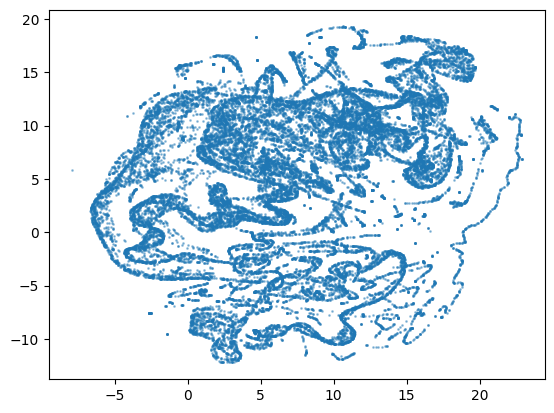

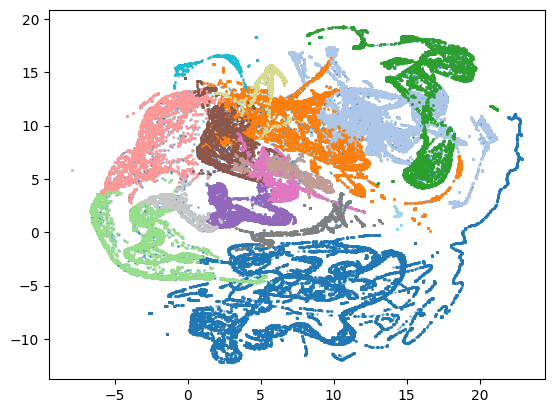

In [71]:
nemi._plot_embedding()
nemi.plot('clusters')

In [73]:
cls_expanded = np.reshape(cls, output_data.shape[0:2])

In [75]:
cls_new_dim = np.expand_dims(cls_expanded, axis=-1)

In [77]:
cls_repeat = np.repeat(cls_new_dim,2,axis=-1)

In [84]:
def split_array_in_half(arr):
    """Splits an array into two halves."""

    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

my_array = nemi.clusters
first_half, second_half = split_array_in_half(my_array)

print(first_half.shape) 
print(second_half.shape) 

(172764,)
(172764,)


In [85]:
cls1 = cls 
cls_copy = copy.copy(cls)

In [86]:
cls1[indmiss].shape

(172764,)

In [87]:
cls_copy[indmiss].shape

(172764,)

In [88]:
cls1[indmiss] = first_half 
cls_copy[indmiss] = second_half 

# Summer clusters 

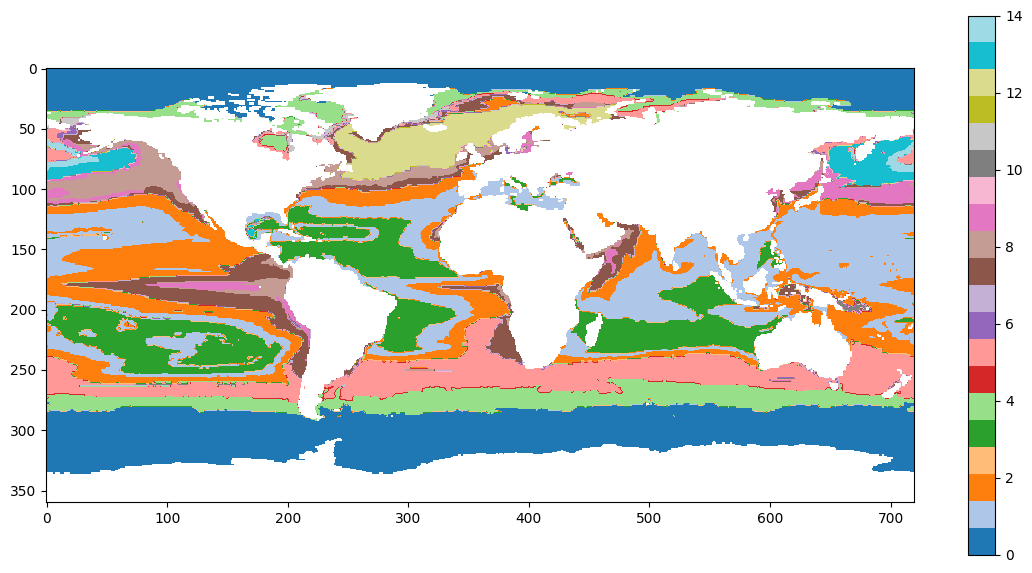

In [90]:
import matplotlib as mpl
plt.figure(figsize=(14,7))
plt.imshow(np.reshape(cls1,output_data.shape[0:2])[::-1,:], cmap=mpl.colormaps['tab20'])
plt.colorbar()

# Winter Clusters 

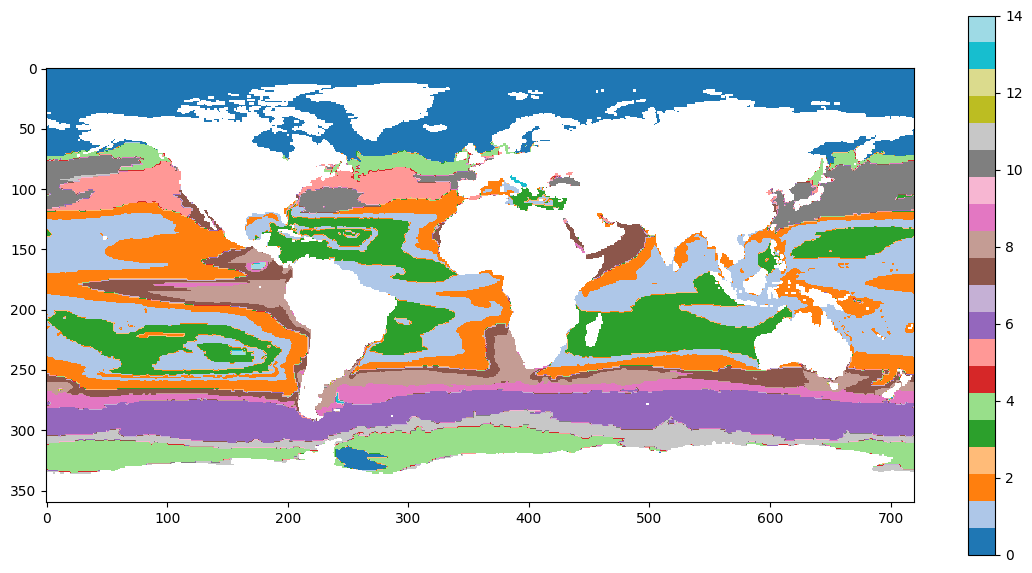

In [91]:
plt.figure(figsize=(14,7))
plt.imshow(np.reshape(cls_copy,output_data.shape[0:2])[::-1,:], cmap=mpl.colormaps['tab20'])
plt.colorbar()

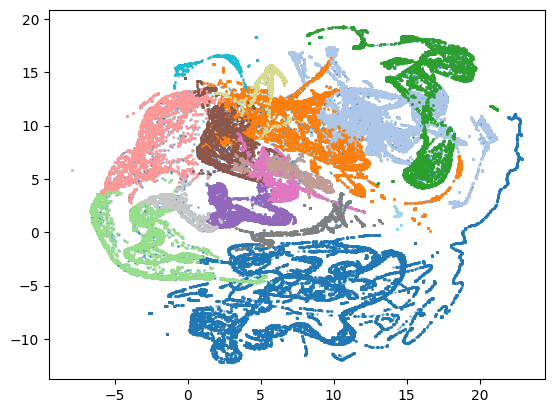

In [98]:
nemi._plot_clusters()